##### 1. Import Libraries & Load Data

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,PowerTransformer,FunctionTransformer,KBinsDiscretizer
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import optuna
import mlflow
import mlflow.xgboost

import os
import joblib


In [2]:
df=pd.read_csv('../data/raw/EasyVisa.csv')

In [3]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [4]:
df.shape

(25480, 12)

In [5]:
cols_to_drop=['case_id','requires_job_training']

binary_yn_cols = ['has_job_experience', 'full_time_position']

ordinal_cols=['education_of_employee']
ordinal_order= [["High School", "Bachelor's", "Master's", "Doctorate"]]

one_hot_cols=['continent', 'region_of_employment']

##### 2. Drop Useless Columns

In [6]:
df.drop(columns=cols_to_drop, inplace=True)

In [7]:
df.shape

(25480, 10)

##### 3. Data Cleaning

In [8]:
(df['no_of_employees']<0).sum()

np.int64(33)

In [9]:
# Fix negative values
df['no_of_employees']=df['no_of_employees'].abs()

In [10]:
(df['no_of_employees']<0).sum()

np.int64(0)

In [11]:
#Normalize prevailing_wage to annual salary

wage_multiplier = {
    'Hour': 2080,
    'Week': 52,
    'Month': 12,
    'Year': 1
}
df['prevailing_wage_annual'] = df['prevailing_wage'] * df['unit_of_wage'].map(wage_multiplier)
 

In [12]:
df.head()

,continent,education_of_employee,has_job_experience,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,prevailing_wage_annual
0,Asia,High School,N,14513,2007,West,592.2029,Hour,Y,Denied,1231782.032
1,Asia,Master's,Y,2412,2002,Northeast,83425.6500,Year,Y,Certified,83425.650
2,Asia,Bachelor's,N,44444,2008,West,122996.8600,Year,Y,Denied,122996.860
3,Asia,Bachelor's,N,98,1897,West,83434.0300,Year,Y,Denied,83434.030
4,Africa,Master's,Y,1082,2005,South,149907.3900,Year,Y,Certified,149907.390


In [13]:
# Drop original wage columns
df.drop(columns=['prevailing_wage', 'unit_of_wage'], inplace=True)

In [14]:
df.shape

(25480, 9)

In [15]:
# creating the date object of today's date
todays_date = date.today()
current_year= todays_date.year

In [16]:
# Use the current year so company_age stays correct (same as the production pipeline)
REFERENCE_YEAR = current_year

In [17]:
df['company_age'] = REFERENCE_YEAR - df['yr_of_estab']

In [18]:
#Drop yr_of_estab — replaced by company_age
df.drop(columns=['yr_of_estab'], inplace=True)

In [19]:
df.head()

,continent,education_of_employee,has_job_experience,no_of_employees,region_of_employment,full_time_position,case_status,prevailing_wage_annual,company_age
0,Asia,High School,N,14513,West,Y,Denied,1231782.032,19
1,Asia,Master's,Y,2412,Northeast,Y,Certified,83425.650,24
2,Asia,Bachelor's,N,44444,West,Y,Denied,122996.860,18
3,Asia,Bachelor's,N,98,West,Y,Denied,83434.030,129
4,Africa,Master's,Y,1082,South,Y,Certified,149907.390,21


In [20]:
df.shape

(25480, 9)

##### 4. Split data into X and y

In [21]:
X=df.drop(columns=['case_status'])
y=df['case_status']

In [22]:
X

,continent,education_of_employee,has_job_experience,no_of_employees,region_of_employment,full_time_position,prevailing_wage_annual,company_age
0,Asia,High School,N,14513,West,Y,1231782.032,19
1,Asia,Master's,Y,2412,Northeast,Y,83425.650,24
2,Asia,Bachelor's,N,44444,West,Y,122996.860,18
3,Asia,Bachelor's,N,98,West,Y,83434.030,129
4,Africa,Master's,Y,1082,South,Y,149907.390,21
...,...,...,...,...,...,...,...,...
25475,Asia,Bachelor's,Y,2601,South,Y,77092.570,18
25476,Asia,High School,Y,3274,Northeast,Y,279174.790,20
25477,Asia,Master's,Y,1121,South,N,146298.850,116
25478,Asia,Master's,Y,1918,West,Y,86154.770,139


In [23]:
y

0           Denied
1        Certified
2           Denied
3           Denied
4        Certified
           ...    
25475    Certified
25476    Certified
25477    Certified
25478    Certified
25479    Certified
Name: case_status, Length: 25480, dtype: object

##### Manual encoding target column

In [24]:
y = np.where(y == 'Certified', 1, 0)

In [25]:
y

array([0, 1, 0, ..., 1, 1, 1], shape=(25480,))

In [26]:
#Identify & Separate Column Types
categorical_features=df.select_dtypes(include='object').columns
numerical_features=df.select_dtypes(include='number').columns

In [27]:
categorical_features=list(categorical_features)
numerical_features=list(numerical_features)

In [28]:
discrete_features=[col for col in numerical_features if df[col].nunique() <=25]
continuous_features=[col for col in numerical_features if df[col].nunique() >25]

In [29]:
print(f"Categorical Features: {categorical_features}")
print(f"Numerical Features: {numerical_features}")
print(f"Discrete Features: {discrete_features}")
print(f"Continuous Features: {continuous_features}")

Categorical Features: ['continent', 'education_of_employee', 'has_job_experience', 'region_of_employment', 'full_time_position', 'case_status']
Numerical Features: ['no_of_employees', 'prevailing_wage_annual', 'company_age']
Discrete Features: []
Continuous Features: ['no_of_employees', 'prevailing_wage_annual', 'company_age']


##### 5. Train-Test Split

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [31]:
print(X_train.shape,X_test.shape)

(20384, 8) (5096, 8)


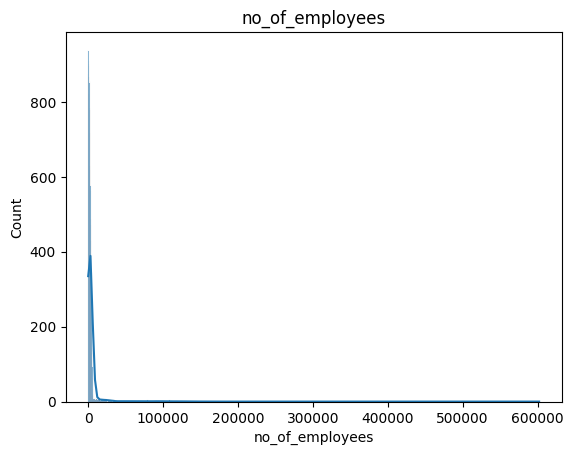

Skewness: 12.541102486449285


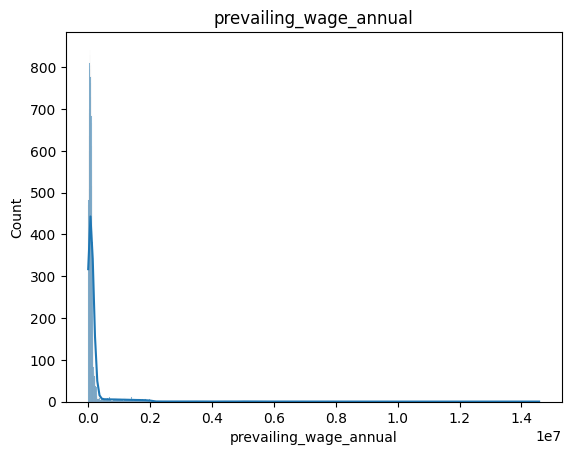

Skewness: 8.980520360967777


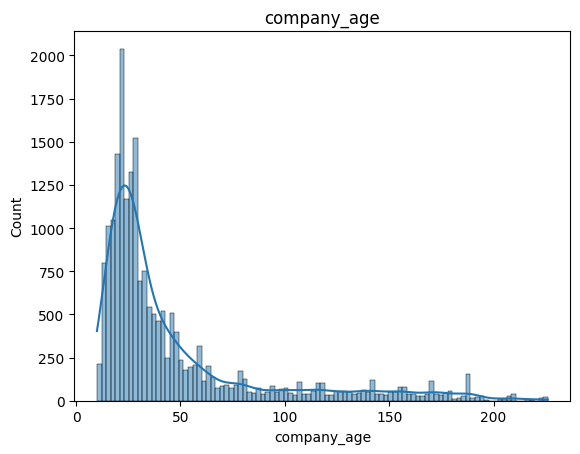

Skewness: 2.0298501419372275


In [32]:
for col in continuous_features:
    sns.histplot(X_train[col], kde=True)
    plt.title(col)
    plt.show()
    
    print("Skewness:", X_train[col].skew())

In [33]:
outlier_list = []

for col in continuous_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_pct = (outlier_count / len(df)) * 100

    action = "Cap" if outlier_pct <= 5 else "Investigate"
    outlier_list.append([col, round(outlier_pct, 2), action])

In [34]:
outlier_list

[['no_of_employees', np.float64(6.11), 'Investigate'],
 ['prevailing_wage_annual', np.float64(9.37), 'Investigate'],
 ['company_age', np.float64(12.79), 'Investigate']]

In [35]:
#Outlier investigation showed that extreme values in features 
# like number of employees, wage, and company age are realistic 
# and represent valid real-world scenarios. Therefore, 
# these are natural outliers and were handled using 
# a power transformation (Yeo-Johnson) instead of removal or capping.
for col in continuous_features:
    print(col)
    
    print("Top 5 values:")
    print(X_train[col].head(5))
    
    print("\n")
    
    print("Bottom 5 values:")
    print(X_train[col].tail(5))
    
    print("-"*20)
    

no_of_employees
Top 5 values:
3516     4069
13759    3022
6019      751
779      1113
22792     796
Name: no_of_employees, dtype: int64


Bottom 5 values:
18469     641
14659    1870
3279      334
16535    2130
16620     272
Name: no_of_employees, dtype: int64
--------------------
prevailing_wage_annual
Top 5 values:
3516      61313.77
13759     36588.11
6019     210280.88
779       46457.53
22792     89542.27
Name: prevailing_wage_annual, dtype: float64


Bottom 5 values:
18469     81581.98
14659      6910.74
3279      68337.50
16535     73886.63
16620    252928.00
Name: prevailing_wage_annual, dtype: float64
--------------------
company_age
Top 5 values:
3516     42
13759    65
6019     55
779      58
22792    47
Name: company_age, dtype: int64


Bottom 5 values:
18469    40
14659    64
3279     26
16535    22
16620    21
Name: company_age, dtype: int64
--------------------


##### 6. Pipeline

In [36]:
transform_cols=['prevailing_wage_annual', 'no_of_employees']
bins_cols=['company_age']

# Numeric transformation
numeric_pipeline = Pipeline([
    ('transform', PowerTransformer(method='yeo-johnson'))
])

# Binary Encoding
def binary_encode(X):
    return (X == 'Y').astype(int)

binary_encoder = FunctionTransformer(
    binary_encode,
    validate=False,
    feature_names_out='one-to-one'
)

# Complete Preprocessor
preprocessor = ColumnTransformer([
    # Binary Features
    ('binary',
     binary_encoder,
     binary_yn_cols),

    # Ordinal Feature
    ('ordinal',
     OrdinalEncoder(
         categories=ordinal_order,
         handle_unknown='use_encoded_value',
         unknown_value=-1
     ),
     ordinal_cols),

    # Nominal Features
    ('onehot',
     OneHotEncoder(
         handle_unknown='ignore',
         sparse_output=False
     ),
     one_hot_cols),

    # Numerical Features
    ('num',
     numeric_pipeline,
     transform_cols),

    # Company Age Bins
    ('bin',
     KBinsDiscretizer(
         n_bins=5,
         encode='ordinal',
         strategy='quantile'
     ),
     bins_cols)
], remainder='drop')

In [37]:
# Fit on train only
preprocessor.fit(X_train)

# Transform
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

/opt/anaconda3/envs/visa_env/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [38]:
print(X_train_processed.shape, X_test_processed.shape)

(20384, 17) (5096, 17)


In [39]:
X_train_processed

array([[ 1.        ,  1.        ,  1.        , ..., -0.2157006 ,
         0.63085188,  3.        ],
       [ 1.        ,  1.        ,  1.        , ..., -0.65188281,
         0.39492641,  4.        ],
       [ 0.        ,  1.        ,  1.        , ...,  0.81897611,
        -0.71724178,  3.        ],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.12427911,
        -1.37008733,  2.        ],
       [ 0.        ,  1.        ,  1.        , ..., -0.0585116 ,
         0.11672641,  1.        ],
       [ 1.        ,  1.        ,  1.        , ...,  0.97321237,
        -1.53608077,  1.        ]], shape=(20384, 17))

In [40]:
X_test_processed

array([[ 1.        ,  1.        ,  2.        , ..., -0.0083239 ,
         0.78082421,  1.        ],
       [ 1.        ,  1.        ,  2.        , ..., -0.51949163,
        -0.8521156 ,  0.        ],
       [ 0.        ,  1.        ,  3.        , ...,  0.10298784,
         0.14932586,  2.        ],
       ...,
       [ 1.        ,  1.        ,  0.        , ..., -0.10060015,
         0.83396849,  3.        ],
       [ 0.        ,  1.        ,  1.        , ...,  0.06242918,
         0.16001794,  4.        ],
       [ 1.        ,  1.        ,  2.        , ...,  0.39244478,
        -0.00907668,  2.        ]], shape=(5096, 17))

In [41]:
feature_names = preprocessor.get_feature_names_out()

In [42]:
feature_names

array(['binary__has_job_experience', 'binary__full_time_position',
       'ordinal__education_of_employee', 'onehot__continent_Africa',
       'onehot__continent_Asia', 'onehot__continent_Europe',
       'onehot__continent_North America', 'onehot__continent_Oceania',
       'onehot__continent_South America',
       'onehot__region_of_employment_Island',
       'onehot__region_of_employment_Midwest',
       'onehot__region_of_employment_Northeast',
       'onehot__region_of_employment_South',
       'onehot__region_of_employment_West', 'num__prevailing_wage_annual',
       'num__no_of_employees', 'bin__company_age'], dtype=object)

In [43]:
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_processed,  columns=feature_names)

In [44]:
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

##### 7. Train Models

In [45]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier( n_estimators=100,random_state=42),
    "AdaBoost Classifier": AdaBoostClassifier(random_state=42),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "CatBoosting Classifier": CatBoostClassifier(verbose=False,random_state=42),
    "Support Vector Classifier": SVC(probability=True,random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),
}

In [46]:
def evaluate_clf(true, predicted):
    acc = accuracy_score(true, predicted)
    f1 = f1_score(true, predicted)
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    return acc, f1, precision, recall

In [47]:
def evaluate_models(X_train, X_test, y_train, y_test, models):
    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc, f1, precision, recall = evaluate_clf(
            y_test,
            y_pred
        )
        results.append({
            "Model": name,
            "Accuracy": round(acc, 4),
            "F1 Score": round(f1, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4)
        })
    return pd.DataFrame(results).sort_values(
        by="Recall",
        ascending=False
    ).reset_index(drop=True)

In [48]:
model_report = evaluate_models(
    X_train_processed,
    X_test_processed,
    y_train,
    y_test,
    models
)

In [49]:
display(model_report)

,Model,Accuracy,F1 Score,Precision,Recall
0,Support Vector Classifier,0.7331,0.8161,0.7561,0.8863
1,AdaBoost Classifier,0.7237,0.8086,0.7525,0.8737
2,Logistic Regression,0.7100,0.8004,0.7408,0.8704
3,CatBoosting Classifier,0.7331,0.8121,0.7666,0.8634
4,XGBoost,0.7212,0.8036,0.7588,0.8540
5,Random Forest,0.7072,0.7887,0.7613,0.8182
6,K-Neighbors Classifier,0.6947,0.7814,0.7488,0.8170
7,Decision Tree,0.6523,0.7379,0.7430,0.7330


8. ##### Hyperparameter Tuning (Optuna)

In [50]:
# Hyperparameter tuning for XGBoost using Optuna
def objective(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        random_state=42,
        eval_metric="logloss"
    )
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    return recall_score(y_test, y_pred)

In [51]:
study=optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=50)

[I 2026-06-24 03:13:33,317] A new study created in memory with name: no-name-f31c1d67-17f5-439a-b4c3-d1ae914961d8
[I 2026-06-24 03:13:33,822] Trial 0 finished with value: 0.8113983548766157 and parameters: {'n_estimators': 157, 'max_depth': 10, 'learning_rate': 0.26978691883462047, 'subsample': 0.791772558477724, 'colsample_bytree': 0.8757506239706311}. Best is trial 0 with value: 0.8113983548766157.
[I 2026-06-24 03:13:34,008] Trial 1 finished with value: 0.8531139835487661 and parameters: {'n_estimators': 116, 'max_depth': 5, 'learning_rate': 0.29687094057554686, 'subsample': 0.9153763405763242, 'colsample_bytree': 0.8704341898491303}. Best is trial 1 with value: 0.8531139835487661.
[I 2026-06-24 03:13:34,616] Trial 2 finished with value: 0.8604582843713279 and parameters: {'n_estimators': 225, 'max_depth': 8, 'learning_rate': 0.03719920697144999, 'subsample': 0.8427240057382521, 'colsample_bytree': 0.970402417194538}. Best is trial 2 with value: 0.8604582843713279.
[I 2026-06-24 03:

In [52]:
print("Best Recall:", study.best_value)
print("Best Params:", study.best_params)

Best Recall: 0.8827849588719154
Best Params: {'n_estimators': 110, 'max_depth': 10, 'learning_rate': 0.024563676146662234, 'subsample': 0.984871310317357, 'colsample_bytree': 0.6741976585164232}


In [53]:
# Hyperparameter tuning for CatBoost using Optuna
def objective(trial):
    model = CatBoostClassifier(
        iterations=trial.suggest_int("iterations", 100, 500),
        depth=trial.suggest_int("depth", 4, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1, 10),
        random_state=42,
        verbose=False
    )
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    return recall_score(y_test, y_pred)

In [54]:
study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective, n_trials=50)

[I 2026-06-24 03:14:25,351] A new study created in memory with name: no-name-5e4d915c-599b-45d2-9626-c6a2c17eba66


[I 2026-06-24 03:14:25,718] Trial 0 finished with value: 0.8648648648648649 and parameters: {'iterations': 150, 'depth': 8, 'learning_rate': 0.05853074060282998, 'l2_leaf_reg': 9.926159150410234}. Best is trial 0 with value: 0.8648648648648649.
[I 2026-06-24 03:14:26,742] Trial 1 finished with value: 0.8589894242068156 and parameters: {'iterations': 406, 'depth': 4, 'learning_rate': 0.2568096673584797, 'l2_leaf_reg': 8.69657065512159}. Best is trial 0 with value: 0.8648648648648649.
[I 2026-06-24 03:14:26,974] Trial 2 finished with value: 0.86427732079906 and parameters: {'iterations': 105, 'depth': 8, 'learning_rate': 0.08026011716305533, 'l2_leaf_reg': 2.879921248561124}. Best is trial 0 with value: 0.8648648648648649.
[I 2026-06-24 03:14:27,646] Trial 3 finished with value: 0.8578143360752056 and parameters: {'iterations': 268, 'depth': 4, 'learning_rate': 0.241517503049963, 'l2_leaf_reg': 7.884249979069548}. Best is trial 0 with value: 0.8648648648648649.
[I 2026-06-24 03:14:29,000

In [55]:
print("Best Recall:", study_cat.best_value)
print("Best Params:", study_cat.best_params)

Best Recall: 0.8710340775558166
Best Params: {'iterations': 226, 'depth': 10, 'learning_rate': 0.015834792932063874, 'l2_leaf_reg': 5.855070273110194}


In [56]:
best_xgb = XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric="logloss"
)

In [57]:
best_xgb.fit(X_train_processed, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6741976585164232
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [58]:
y_pred = best_xgb.predict(X_test_processed)

In [59]:
acc, f1, precision, recall = evaluate_clf(y_test,y_pred)

In [60]:
print(acc, f1, precision, recall)

0.7264521193092621 0.81172339276067 0.75125 0.8827849588719154


In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.41      0.50      1692
           1       0.75      0.88      0.81      3404

    accuracy                           0.73      5096
   macro avg       0.69      0.65      0.66      5096
weighted avg       0.71      0.73      0.71      5096



### Final Model Selection


##### Although SVC achieved the highest recall, XGBoost produced very similar results and is a more robust and widely adopted model for tabular data. Therefore, XGBoost was chosen as the final model.

9. ##### threshold tuning

In [65]:
proba = best_xgb.predict_proba(X_test_processed)[:, 1]

In [66]:
proba

array([0.84169376, 0.9089153 , 0.83069855, ..., 0.38236094, 0.39072654,
       0.90486395], shape=(5096,), dtype=float32)

In [68]:
for threshold in [0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred = (proba >= threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1 Score :", round(f1_score(y_test, y_pred), 4))


Threshold: 0.3
Accuracy : 0.6858
Precision: 0.6831
Recall   : 0.988
F1 Score : 0.8077

Threshold: 0.35
Accuracy : 0.6947
Precision: 0.6933
Recall   : 0.9736
F1 Score : 0.8099

Threshold: 0.4
Accuracy : 0.709
Precision: 0.7107
Recall   : 0.9518
F1 Score : 0.8138

Threshold: 0.45
Accuracy : 0.7194
Precision: 0.7307
Recall   : 0.9183
F1 Score : 0.8139

Threshold: 0.5
Accuracy : 0.7265
Precision: 0.7512
Recall   : 0.8828
F1 Score : 0.8117


In [70]:
joblib.dump(best_xgb, "../artifacts/model.pkl")
joblib.dump(preprocessor, "../artifacts/preprocessor.pkl")
joblib.dump(0.45, "../artifacts/threshold.pkl")

['../artifacts/threshold.pkl']

In [77]:
y_pred = (proba >= 0.45).astype(int)

##### 10. MLFlow

In [78]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [79]:
print(accuracy, precision, recall, f1)

0.7193877551020408 0.7307152875175316 0.918331374853114 0.813850559750065


In [81]:
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Force MLflow to use project_root/mlruns

tracking_path = f"file://{project_root}/mlruns"

mlflow.set_tracking_uri(tracking_path)

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: file:///Users/mitpatel/Desktop/usvisaprediction/mlruns


In [83]:
# Allow MLflow file store (MLflow 3.x fix)
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

# Save runs in project_root/mlruns
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

mlflow.set_tracking_uri(
    f"file://{project_root}/mlruns"
)

mlflow.set_experiment("US Visa Prediction - XGBoost")

with mlflow.start_run():

    # Log parameters
    mlflow.log_params(study.best_params)
    mlflow.log_param("threshold", 0.45)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Log model
    mlflow.xgboost.log_model(
        best_xgb,
        name="xgboost_model"
    )

print("MLflow run completed!")

2026/06/24 03:59:04 INFO mlflow.tracking.fluent: Experiment with name 'US Visa Prediction - XGBoost' does not exist. Creating a new experiment.


MLflow run completed!


### Final Model

##### XGBoost was selected as the final model due to its strong performance after hyperparameter tuning with Optuna. To further improve recall, threshold tuning was performed and a threshold of 0.45 was selected. The final model achieved high recall and demonstrated good predictive performance on unseen data, making it suitable for visa status prediction.